In [2]:
#import libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import RepeatedStratifiedKFold

In [3]:
#pull the cleaned data
df = pd.read_csv('rest_review_data_cleaned.csv')

In [4]:
#pull vectorized data
bag_df=pd.read_csv('bag_dfcsv')
tfidf_df=pd.read_csv('tfidf_df.csv')
ngram_df=pd.read_csv('ngram_df.csv')

In [5]:
#Model Selection
#Split the dataset
X=df[['Review_cleaned']]
y=df['Liked']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
X_bag = bag_df
X_tfidf = tfidf_df
X_ngram = ngram_df

#Split the dataset for vectorized datasets
X_bag_train, X_bag_test, y_bag_train, y_bag_test = train_test_split(X_bag, y, test_size=0.2, random_state=42)
X_tfidf_train, X_tfidf_test, y_tfidf_train, y_tfidf_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)
X_ngram_train, X_ngram_test, y_ngram_train, y_ngram_test = train_test_split(X_ngram, y, test_size=0.2, random_state=42)

In [7]:
#Model building
dt = DecisionTreeClassifier()
lr = LogisticRegression()
svc = SVC()
rf = RandomForestClassifier()
Bayes = BernoulliNB()
KNN = KNeighborsClassifier()

Models = [dt, lr, svc, rf, Bayes, KNN]
Models_Dict = {0: "Decision Tree", 1: "Logistic Regression", 2: "SVC", 3: "Random Forest", 4: "Naive Bayes", 5: "K-Neighbors"}

In [8]:
for i, model in enumerate(Models):
  print("{} Accuracy with Bag of Words data: {}".format(Models_Dict[i], cross_val_score(model, X_bag_train, y_bag_train, cv = 10, scoring = "accuracy").mean()))
  print("{} Accuracy with TF-IDF data: {}".format(Models_Dict[i], cross_val_score(model, X_tfidf_train, y_tfidf_train, cv = 10, scoring = "accuracy").mean()))
  print("{} Accuracy with N-gram data: {}".format(Models_Dict[i], cross_val_score(model, X_ngram_train, y_ngram_train, cv = 10, scoring = "accuracy").mean()))


Decision Tree Accuracy with Bag of Words data: 0.69875
Decision Tree Accuracy with TF-IDF data: 0.70625
Decision Tree Accuracy with N-gram data: 0.5725
Logistic Regression Accuracy with Bag of Words data: 0.7762499999999999
Logistic Regression Accuracy with TF-IDF data: 0.7925
Logistic Regression Accuracy with N-gram data: 0.57125
SVC Accuracy with Bag of Words data: 0.7775
SVC Accuracy with TF-IDF data: 0.78625
SVC Accuracy with N-gram data: 0.58
Random Forest Accuracy with Bag of Words data: 0.74
Random Forest Accuracy with TF-IDF data: 0.7575000000000001
Random Forest Accuracy with N-gram data: 0.5725
Naive Bayes Accuracy with Bag of Words data: 0.7562499999999999
Naive Bayes Accuracy with TF-IDF data: 0.7562499999999999
Naive Bayes Accuracy with N-gram data: 0.5725
K-Neighbors Accuracy with Bag of Words data: 0.6787500000000001
K-Neighbors Accuracy with TF-IDF data: 0.72875
K-Neighbors Accuracy with N-gram data: 0.51625


In [9]:
param_grid_lr = {
    'max_iter': [20, 50, 100, 200, 500, 1000],                      
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],   
    'class_weight': ['balanced']}

grid_search=GridSearchCV(estimator=LogisticRegression(random_state=42), param_grid=param_grid_lr, verbose=1, cv=10, n_jobs=-1)
    

In [10]:
# fitting the model for grid search
grid_search.fit(X_tfidf_train, y_tfidf_train)
best_accuracy = grid_search.best_score_
best_parameters = grid_search.best_params_
best_estimator = grid_search.best_estimator_
print("Best Accuracy: {:.2f} %".format(best_accuracy*100))
print("Best Parameters:", best_parameters)
print("Best Estimator:", best_estimator)

#Best Model
'''Classifier = LogisticRegression(class_weight='balanced', max_iter=20, random_state=42,
                   solver='newton-cg')
Classifier.fit(X_tfidf_train, y_tfidf_train)
'''
Prediction = grid_search.predict(X_tfidf_test)
print('Test Accuracy: ', grid_search.score(X_tfidf_test, y_tfidf_test))

Fitting 10 folds for each of 30 candidates, totalling 300 fits


/Users/derinberktay/Desktop/restaurant_review_analysis-main/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/derinberktay/Desktop/restaurant_review_analysis-main/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/derinberktay/Desktop/restaurant_review_analysis-main/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/derinberktay/Desktop/restaurant_review_analysis-main/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/derinberktay/Desktop/restaurant_review_analysis-main/.venv/lib/python3.12

Best Accuracy: 79.12 %
Best Parameters: {'class_weight': 'balanced', 'max_iter': 20, 'solver': 'lbfgs'}
Best Estimator: LogisticRegression(class_weight='balanced', max_iter=20, random_state=42)
Test Accuracy:  0.77


In [11]:
#Metrics
accuracy_score(y_tfidf_test, Prediction)

#Confusion Matrix
ConfusionMatrix = confusion_matrix(y_tfidf_test, Prediction)

# Plotting Function for Confusion Matrix
colors = ['#4F6272', '#DD7596']

Unnormalized Confusion Matrix
              precision    recall  f1-score   support

           0       0.72      0.86      0.78        96
           1       0.85      0.68      0.76       104

    accuracy                           0.77       200
   macro avg       0.78      0.77      0.77       200
weighted avg       0.78      0.77      0.77       200



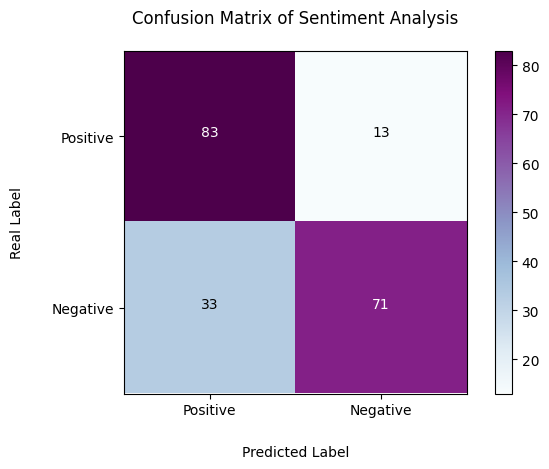

In [12]:

def plot_cm(cm, classes, title, normalized = False, cmap = plt.cm.BuPu):
    plt.imshow(cm, interpolation = "nearest", cmap = cmap)
    plt.title(title, pad = 20)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes)
    plt.yticks(tick_marks, classes)
    

    if normalized:
        cm = cm.astype('float') / cm.sum(axis = 1)[: np.newaxis]
        print("Normalized Confusion Matrix")
    else:
        print("Unnormalized Confusion Matrix")
  
    threshold = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], horizontalalignment = "center", color = "white" if cm[i, j] > threshold else "black")

    plt.tight_layout()
    plt.xlabel("Predicted Label", labelpad = 20)
    plt.ylabel("Real Label", labelpad = 20)
    
plot_cm(ConfusionMatrix, classes = ["Positive", "Negative"], title = "Confusion Matrix of Sentiment Analysis")
plt.tight_layout()
plt.savefig('images/confusion_matrix.png', dpi=300)

print(classification_report(y_tfidf_test, Prediction))
